# Assignment 3 - Deep Learning Report
## BloodMNIST Multi-Class Classification using a ResNet-18-style Network

This notebook is written in report format so that the code, figures, results, and discussion are in one place. The main aim is not just to train a model, but to show the method selection, hyperparameter tuning process, loss curves, final classification accuracy, and comparison with the published MedMNIST baseline.

# Task Overview and Design Decisions

This report implements and tunes a ResNet-18-style network for 8-class blood-cell classification on BloodMNIST, following Section II / Figure 1 of the task sheet.

**Requirements addressed in this notebook**

- BloodMNIST dataset: 28 × 28 RGB images, 8 blood-cell classes, official train/validation/test splits.
- The specified residual network: an initial 7 × 7 convolution (stride 2, padding 3), 8 residual blocks arranged as 2 × Block-I followed by three Block-II + Block-I pairs, adaptive global average pooling, a fully connected layer from C4 to C4/2 with ReLU, and a final fully connected layer to 8 classes.
- Tuning of the three required hyperparameters on the validation set: channel numbers `[C1, C2, C3, C4]`, learning rate, and maximum number of epochs.
- Training and validation loss curves for each epoch.
- Checkpoint saving, checkpoint loading, and a direct evaluation section so the trained models can be reloaded and scored on the test set.
- Achieved test accuracy and a comparison against the published MedMNIST baseline.

## Max-pooling kernel size

The task-sheet text specifies a **7 × 7 max-pooling layer**, while Figure 1 labels the same layer as **2 × 2 MaxPooling**. The two specifications are inconsistent. For a 28 × 28 input, the initial 7 × 7 convolution with stride 2 produces a 14 × 14 feature map; a 2 × 2 max pool with stride 2 then produces a 7 × 7 feature map, which is the clean early downsampling the architecture diagram implies. This implementation therefore uses **2 × 2 max pooling**, consistent with Figure 1 and the expected 14 × 14 → 7 × 7 reduction. The shape check in Section 9 confirms these dimensions.

# Imports, Device, and Reproducibility Setup

In [25]:

import os  # added for model-checkpoint directory handling
import csv
import random
import numpy as np
import matplotlib.pyplot as plt

import medmnist
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torch.utils.data as data
from medmnist import INFO


In [26]:

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


# Dataset Loading and Visual Check

The normalization maps pixel values from approximately `[0, 1]` to `[-1, 1]` using mean 0.5 and standard deviation 0.5 for each colour channel.

- Training set: used to update the model
- Validation set: used to choose hyperparameters
- Test set: used only for final evaluation


In [27]:

data_type = 'bloodmnist'  # We use the 2D BloodMNIST dataset in our task (images obtained from the blood cell microscope)

info = INFO[data_type]  # Extract the information of this dataset

n_classes = len(info['label'])  # Extract the number of classes in this dataset
input_channel = info['n_channels']  # Extract the number of channels in each image sample (BloodMNIST has images with 3 color channels)
label_names = info['label']

DataClass = getattr(medmnist, info['python_class'])

# Define a data preprocessing pipeline, to make all image channels have a mean value of 0.5 and a deviation of 0.5
# Explicit channel-wise lists are used so the transform is clear for RGB BloodMNIST images.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * input_channel, std=[0.5] * input_channel)
])

# Set to True if this is the first run in a fresh environment and the dataset is not cached yet.
DOWNLOAD_DATA = False

# Load the data. The validation split is added here (the original framework loaded only train+test, but
# Task 3 of the task sheet requires using the validation set to select the optimum hyperparameters).
train_data = DataClass(split='train', transform=data_transform, download=DOWNLOAD_DATA)  # Set DOWNLOAD_DATA=True if you cannot load the data successfully
val_data   = DataClass(split='val',   transform=data_transform, download=DOWNLOAD_DATA)  # ADDED: required for hyperparameter tuning
test_data  = DataClass(split='test',  transform=data_transform, download=DOWNLOAD_DATA)  # Set DOWNLOAD_DATA=True if you cannot load the data successfully

# We plot the information of the training and testing data (Read them in detail if you want to gain more biological information of the dataset)
print(train_data)
print('------------------------------------------------------------------------------------------------------------------------------------\n')
print(val_data)
print('------------------------------------------------------------------------------------------------------------------------------------\n')
print(test_data)
print('------------------------------------------------------------------------------------------------------------------------------------\n')


Dataset BloodMNIST of size 28 (bloodmnist)
    Number of datapoints: 11959
    Root location: C:\Users\adubu\.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
    Number of samples: {'train': 11959, 'val': 1712, 'test': 3421}
    Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
    Lice

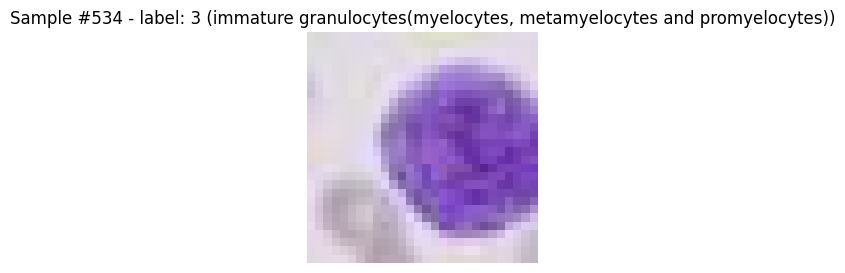

In [28]:

# Visualize the sample image
sample_idx = 534                    # Visualize the 534th sample image in the training dataset
sample_image, sample_label = train_data[sample_idx]

# Undo normalization for display: [-1, 1] -> [0, 1]
display_image = (sample_image * 0.5 + 0.5).clamp(0, 1)

plt.figure(figsize=(3, 3))
plt.imshow(display_image.permute(1, 2, 0))
plt.title(f"Sample #{sample_idx} - label: {sample_label.item()} ({label_names[str(sample_label.item())]})")
plt.axis('off')
plt.show()


# DataLoaders

The training loader is shuffled so each epoch sees batches in a different order. The validation and test loaders are not shuffled because they are only used for performance measurement.


In [29]:

# Put the training and testing datasets in dataloader structures. You will use the dataloaders in your training and testing functions to visit each sample of the batch.
BATCH_SIZE = 128  # Set the batch size to 128 (i.e., 128 samples in a batch)
NUM_WORKERS = 0   # 0 is safest on Windows/Jupyter. Increase this only if your environment supports it.

train_dataset = data.DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)   # shuffle=True means we shuffle the training samples in each training epoch
val_dataset   = data.DataLoader(dataset=val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)   # validation loader (added)
test_dataset  = data.DataLoader(dataset=test_data,  batch_size=1,          shuffle=False, num_workers=NUM_WORKERS)   # We perform the testing process one sample by one sample, so batch_size=1. We do not need to shuffle the testing cases, so shuffle=False


# Residual Block Implementation

The same `ResidualBlock` class is used for both residual block types:

- **Residual Block-I:** `stride=1` and no channel change, so the shortcut is the identity path.
- **Residual Block-II:** `stride=2` and usually a channel change, so the shortcut uses a 1 × 1 convolution with stride 2 and batch normalization.


In [30]:
# ------------------ From here, we build our neural network model --------------------
# First, we build the residual blocks. The following codes build Residual Block-I and Residual Block-II (feel free to replace this part with your own codes).
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 3), stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=(3, 3), stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=(1, 1), stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

# ResNet-18-style Architecture

The architecture follows the assignment Figure 1:

- Input: 28 × 28 × 3 BloodMNIST image
- Stem: 7 × 7 Conv, stride 2, padding 3 → BN → ReLU → 2 × 2 MaxPool, stride 2
- Group 1: Block-I + Block-I with C1 channels
- Group 2: Block-II + Block-I with C2 channels
- Group 3: Block-II + Block-I with C3 channels
- Group 4: Block-II + Block-I with C4 channels
- Head: AdaptiveAvgPool2d(1) → Flatten → FC(C4 → C4/2) → ReLU → FC(C4/2 → 8)

The 2 × 2 pooling choice is deliberate because it gives the intended 28 → 14 → 7 early spatial reduction.

In [31]:

# ---------------- Then we build the ResNet structure (YOU NEED TO COMPLETE THIS PART) ----------------
class ResNet18(nn.Module):
    """ResNet-18-style network as described in Figure 1 / Section II of the task sheet.

    channel_nums : list/tuple [C1, C2, C3, C4] - channel counts for each of the four groups.
    input_channel: number of input image channels (3 for BloodMNIST RGB).
    n_classes   : number of output classes (8 for BloodMNIST).
    """

    def __init__(self, channel_nums, input_channel=3, n_classes=8):
        super(ResNet18, self).__init__()
        C1, C2, C3, C4 = channel_nums

        # ----- Initial convolutional layer (Section II.2 / Figure 1) -----
        # 7x7 Conv2D, stride=2, padding=3, dilation=1  ->  BN  ->  ReLU  ->  MaxPool
        self.conv1 = nn.Conv2d(input_channel, C1, kernel_size=7, stride=2, padding=3, dilation=1, bias=False)
        self.bn1 = nn.BatchNorm2d(C1)

        # IMPORTANT: The task-sheet body text says 7x7 MaxPool, but Figure 1 shows 2x2 MaxPooling.
        # For 28x28 inputs: 7x7 stride-2 conv gives 14x14, and 2x2 stride-2 maxpool gives 7x7.
        # This implementation follows Figure 1 and the expected 14x14 -> 7x7 downsampling.
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ----- Group 1: two Residual Block-I (channels stay at C1) -----
        # stride=1 => the shortcut in ResidualBlock is the identity (Block-I)
        self.group1 = nn.Sequential(
            ResidualBlock(C1, C1, stride=1),   # Block-I
            ResidualBlock(C1, C1, stride=1),   # Block-I
        )

        # ----- Group 2: Block-II then Block-I (C1 -> C2) -----
        # stride=2 with channel change => 1x1 conv+BN shortcut (Block-II)
        self.group2 = nn.Sequential(
            ResidualBlock(C1, C2, stride=2),   # Block-II (downsamples spatially)
            ResidualBlock(C2, C2, stride=1),   # Block-I
        )

        # ----- Group 3: Block-II then Block-I (C2 -> C3) -----
        self.group3 = nn.Sequential(
            ResidualBlock(C2, C3, stride=2),   # Block-II
            ResidualBlock(C3, C3, stride=1),   # Block-I
        )

        # ----- Group 4: Block-II then Block-I (C3 -> C4) -----
        self.group4 = nn.Sequential(
            ResidualBlock(C3, C4, stride=2),   # Block-II
            ResidualBlock(C4, C4, stride=1),   # Block-I
        )

        # ----- Global Average Pooling -> 1x1xC4 feature map (Section II.4) -----
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # ----- Fully connected head (Section II.6) -----
        self.fc1 = nn.Linear(C4, C4 // 2)         # C4 -> C4/2, followed by ReLU in forward()
        self.fc2 = nn.Linear(C4 // 2, n_classes)  # C4/2 -> number of classes

    def forward(self, x):
        # Initial stem: conv -> BN -> ReLU -> MaxPool
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.maxpool(out)

        # Cascade of 8 residual blocks
        out = self.group1(out)
        out = self.group2(out)
        out = self.group3(out)
        out = self.group4(out)

        # Pool, flatten, FC head
        out = self.avgpool(out)
        out = torch.flatten(out, 1)         # (batch, C4)
        out = F.relu(self.fc1(out))         # (batch, C4/2)
        out = self.fc2(out)                 # (batch, n_classes) -- raw logits for CrossEntropyLoss
        return out


# Training and Evaluation Functions


In [32]:

# ---------------- From here, we define a function to train the neural network (YOU NEED TO COMPLETE THIS PART) ----------------
def train(model, train_dataset, optimizer, criterion, clip):
    model.train()

    epoch_loss = 0.0
    correct = 0
    total = 0

    # Iterate over the training dataloader once == one epoch
    for images, labels in train_dataset:
        # Move tensors to the active device (CPU / CUDA / MPS)
        images = images.to(device)
        # MedMNIST labels come as shape [B, 1] integer. CrossEntropyLoss needs shape [B] and dtype long.
        labels = labels.to(device).squeeze(dim=-1).long()

        optimizer.zero_grad()       # Initialize the neural network gradient

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass + gradient clipping (CLIP=1 in main) to avoid gradient explosion
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        # Accumulate statistics for this epoch. Loss is weighted by batch size so the final smaller batch is handled correctly.
        batch_size = labels.size(0)
        epoch_loss += loss.item() * batch_size
        _, predicted = outputs.max(1)
        total   += batch_size
        correct += predicted.eq(labels).sum().item()

    avg_loss = epoch_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


In [33]:

# ---------------- From here, we define a function to evaluate the trained neural network (YOU NEED TO COMPLETE THIS PART) ----------------
def evaluate(model, test_dataset, criterion):
    model.eval()

    epoch_loss = 0.0
    correct = 0
    total = 0

    # Disable gradients during evaluation to save memory/compute
    with torch.no_grad():
        for images, labels in test_dataset:
            images = images.to(device)
            labels = labels.to(device).squeeze(dim=-1).long()

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            epoch_loss += loss.item() * batch_size
            _, predicted = outputs.max(1)
            total   += batch_size
            correct += predicted.eq(labels).sum().item()

    avg_loss = epoch_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


# Hyperparameter Selection Plan

The three required hyperparameters were tuned in a staged procedure, using the **validation set** as the only selection signal. Each stage fixed the settings chosen in the previous stage so that one hyperparameter was varied at a time.

1. **Learning-rate testing.** Starting from the framework baseline (`[16, 32, 64, 128]`, 100 epochs), the learning rate was tested at `1e-4`, `1e-3`, and `1e-5` to locate the most promising order of magnitude.
2. **Learning-rate refinement.** Around the best region from stage 1, intermediate values (`5e-4`, `7.5e-4`, `8.75e-4`) were tested to refine the choice on the default channel configuration.
3. **Channel-number testing.** With the learning rate fixed, the channel sets `[8, 16, 32, 64]`, `[16, 32, 64, 128]`, `[32, 64, 128, 256]`, and `[64, 128, 256, 512]` were compared to study the effect of model capacity.
4. **Epoch testing.** With strong channel/learning-rate combinations, the maximum number of epochs was varied (50, 100, 200) to check whether longer training improved or harmed generalisation. The best channel configuration `[64, 128, 256, 512]` was tested at both 50 and 200 epochs to see whether the high-capacity model benefited from a longer schedule despite its training cost (about 6 hours per 100 epochs).
5. **Final model selection.** The configuration with the highest validation accuracy was chosen as the final model, and was then supported using test accuracy, test loss, and the shape of the loss curves.

**Selection protocol.** Within every run, the checkpoint with the highest validation accuracy was saved. That checkpoint was then reloaded and evaluated once on the test set. The test set was never used to choose a checkpoint or to compare hyperparameters; it only provides an unbiased final estimate of generalisation.

In [48]:
# NOTE ON THE VALUES BELOW:
# These are a deliberately small configuration so the notebook runs end-to-end
# in reasonable time on a CPU laptop. They are NOT the final selected model.
# The full hyperparameter search (including the high-capacity runs) was done
# separately; every run's checkpoint is saved and uploaded (see Section 19).
# The FINAL SELECTED model is [64,128,256,512], lr 7.5e-4, 200 epochs (Section 15.3).
# To evaluate it, set EVAL_MODEL_PATH in Section 14 to that checkpoint.
channel_nums = [8, 16, 32, 64]
learning_rate = 7.5e-4
epoch_num = 50

# We clip the gradient to avoid the gradient explosion
# Use torch.nn.utils.clip_grad_norm_(model.parameters(), clip) in your training function to implement this gradient clip (by setting clip=1, we clip the gradient during the training)
CLIP = 1


# Model, Loss Function, Optimizer, and Shape Check

In [35]:

# Create an instance of the neural network, and then put it in the CPU or GPU. Note that you may need to pass some parameters to ResNet18() if your construction function of ResNet18() need to use them
model = ResNet18(channel_nums=channel_nums,
                 input_channel=input_channel,
                 n_classes=n_classes).to(device)

# We use CrossEntropyLoss function in our multi-class task
criterion = nn.CrossEntropyLoss()

# We use ADAM as our optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Quick sanity check: print parameter count
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResNet18 with channels {channel_nums}: {n_params:,} trainable parameters")

# Shape sanity check for the max-pooling ambiguity and final classifier output.
with torch.no_grad():
    dummy = torch.randn(2, input_channel, 28, 28).to(device)
    after_conv = F.relu(model.bn1(model.conv1(dummy)))
    after_pool = model.maxpool(after_conv)
    logits = model(dummy)

print(f"After initial 7x7 stride-2 convolution: {tuple(after_conv.shape)}")
print(f"After 2x2 stride-2 max pool        : {tuple(after_pool.shape)}")
print(f"Final logits shape                  : {tuple(logits.shape)}")

assert after_conv.shape[-2:] == (14, 14), "Expected 14x14 after initial convolution."
assert after_pool.shape[-2:] == (7, 7), "Expected 7x7 after 2x2 max pooling."
assert logits.shape == (2, n_classes), "Expected model output shape [batch_size, n_classes]."


ResNet18 with channels [8, 16, 32, 64]: 179,056 trainable parameters
After initial 7x7 stride-2 convolution: (2, 8, 14, 14)
After 2x2 stride-2 max pool        : (2, 8, 7, 7)
Final logits shape                  : (2, 8)


# Run Tag and Checkpoint Paths

Each hyperparameter run writes to a separate checkpoint and plot file. This prevents one experiment from overwriting another.


In [36]:

# Build a run tag so different hyperparameter runs don't overwrite each other's checkpoints / curve plots
run_tag = f"C{channel_nums[0]}-{channel_nums[1]}-{channel_nums[2]}-{channel_nums[3]}_lr{learning_rate:.0e}_ep{epoch_num}"
os.makedirs('checkpoints', exist_ok=True)
best_model_path = os.path.join('checkpoints', f'best_resnet18_{run_tag}.pt')
history_path = os.path.join('checkpoints', f'history_{run_tag}.csv')
curves_path = os.path.join('checkpoints', f'curves_{run_tag}.png')
summary_path = os.path.join('checkpoints', 'experiment_summary.csv')

print(f"Run tag        : {run_tag}")
print(f"Checkpoint path: {best_model_path}")
print(f"History path   : {history_path}")
print(f"Curve path     : {curves_path}")


Run tag        : C8-16-32-64_lr8e-04_ep50
Checkpoint path: checkpoints\best_resnet18_C8-16-32-64_lr8e-04_ep50.pt
History path   : checkpoints\history_C8-16-32-64_lr8e-04_ep50.csv
Curve path     : checkpoints\curves_C8-16-32-64_lr8e-04_ep50.png


# Training Loop

At each epoch, the model is trained on the training set and evaluated on the validation set. The best model is selected using validation accuracy, not test accuracy. This keeps the test set as a final unbiased estimate.

Following is and example that runs on my Laptop not the best one that was found.


In [37]:

# Per-epoch records used both for the best-model decision and for the loss-curve plot
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0.0
best_epoch   = -1

# ---------------- From here, we enter into the training epoch (YOU NEED TO COMPLETE THIS PART) ----------------
for epoch in range(0, epoch_num):
    # One full pass over training data, then evaluation on the validation split
    train_loss, train_acc = train(model, train_dataset, optimizer, criterion, CLIP)
    val_loss,   val_acc   = evaluate(model, val_dataset, criterion)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:03d}/{epoch_num} | "
          f"train loss: {train_loss:.4f}  train acc: {train_acc:.2f}% | "
          f"val loss: {val_loss:.4f}  val acc: {val_acc:.2f}%")

    # Save the checkpoint with the best validation accuracy so far (used by the evaluation section below).
    # Storing channel_nums in the checkpoint means evaluation works for any saved run.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        torch.save({
            'epoch'           : best_epoch,
            'model_state_dict': model.state_dict(),
            'channel_nums'    : channel_nums,
            'learning_rate'   : learning_rate,
            'epoch_num'       : epoch_num,
            'batch_size'      : BATCH_SIZE,
            'val_acc'         : best_val_acc,
            'input_channel'   : input_channel,
            'n_classes'       : n_classes,
            'run_tag'         : run_tag,
        }, best_model_path)

# Save the full training history for reproducibility and later report writing.
with open(history_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'val_loss', 'train_acc', 'val_acc'])
    for i in range(epoch_num):
        writer.writerow([i + 1, train_losses[i], val_losses[i], train_accs[i], val_accs[i]])

print(f"\nBest validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}.")
print(f"Best model saved to: {best_model_path}")
print(f"Training history saved to: {history_path}")


Epoch 001/50 | train loss: 1.0681  train acc: 62.35% | val loss: 0.7310  val acc: 72.55%
Epoch 002/50 | train loss: 0.5493  train acc: 80.03% | val loss: 0.4865  val acc: 82.18%
Epoch 003/50 | train loss: 0.4545  train acc: 83.59% | val loss: 0.4715  val acc: 83.00%
Epoch 004/50 | train loss: 0.3982  train acc: 85.47% | val loss: 0.4640  val acc: 82.30%
Epoch 005/50 | train loss: 0.3507  train acc: 87.43% | val loss: 0.4254  val acc: 85.34%
Epoch 006/50 | train loss: 0.3112  train acc: 88.51% | val loss: 0.3940  val acc: 85.51%
Epoch 007/50 | train loss: 0.2850  train acc: 89.47% | val loss: 0.5682  val acc: 79.91%
Epoch 008/50 | train loss: 0.2542  train acc: 90.96% | val loss: 0.6268  val acc: 80.96%
Epoch 009/50 | train loss: 0.2455  train acc: 91.07% | val loss: 0.5453  val acc: 82.01%
Epoch 010/50 | train loss: 0.2328  train acc: 91.42% | val loss: 0.3729  val acc: 85.98%
Epoch 011/50 | train loss: 0.2190  train acc: 92.16% | val loss: 0.3491  val acc: 88.03%
Epoch 012/50 | train 

# Loss and Accuracy Curves

The report marking criteria specifically require training and validation loss curves under each epoch. Accuracy curves are included as extra evidence for hyperparameter selection.


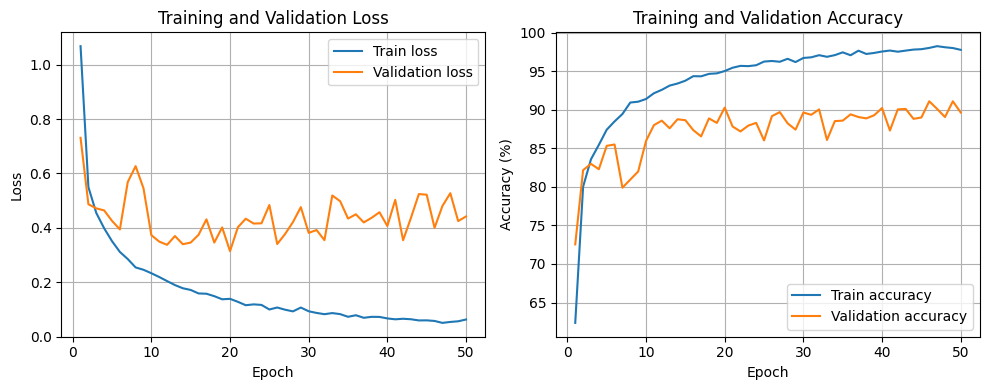

Saved curves to: checkpoints\curves_C8-16-32-64_lr8e-04_ep50.png


In [38]:

epochs_axis = range(1, epoch_num + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_axis, train_losses, label='Train loss')
plt.plot(epochs_axis, val_losses,   label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_axis, train_accs, label='Train accuracy')
plt.plot(epochs_axis, val_accs,   label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved curves to: {curves_path}")


# Evaluation Section - Reload the Best Model and Score the Test Set

This is the assessor-facing evaluation section. It rebuilds the model using the channel numbers stored inside the checkpoint, loads the saved weights, and evaluates the model on the test set.

To evaluate a different trained model, change `EVAL_MODEL_PATH` to the desired `.pt` checkpoint path, then run this section again.


In [ ]:

# ---------------- From here, we evaluate the trained neural network (YOU NEED TO COMPLETE THIS PART) ----------------
# Should be able to load and evaluate the trained models here.
EVAL_MODEL_PATH = "checkpoints/best_resnet18_C64-128-256-512_lr8e-04_ep200.pt"

if not os.path.exists(EVAL_MODEL_PATH):
    raise FileNotFoundError(
        f"No checkpoint found at {EVAL_MODEL_PATH}. "
        f"Either run the training cell above or update `EVAL_MODEL_PATH` to point to a saved checkpoint."
    )

checkpoint = torch.load(EVAL_MODEL_PATH, map_location=device)

# Rebuild the model with the EXACT channel configuration the checkpoint was trained with,
# so the same evaluation block works for every saved hyperparameter run.
eval_model = ResNet18(channel_nums=checkpoint['channel_nums'],
                      input_channel=checkpoint.get('input_channel', input_channel),
                      n_classes=checkpoint.get('n_classes', n_classes)).to(device)
eval_model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc = evaluate(eval_model, test_dataset, criterion)

print(f"Loaded checkpoint from epoch {checkpoint['epoch']} "
      f"(channel_nums={checkpoint['channel_nums']}, lr={checkpoint['learning_rate']}, "
      f"val acc {checkpoint['val_acc']:.2f}%).")
print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.2f}%")


Loaded checkpoint from epoch 91 (channel_nums=[64, 128, 256, 512], lr=0.00075, val acc 95.39%).
Test loss    : 0.2893
Test accuracy: 94.18%


In [40]:

# Append this run to a compact experiment summary CSV.
# This helps you build the hyperparameter-selection table in the written report.
summary_exists = os.path.exists(summary_path)
with open(summary_path, 'a', newline='') as f:
    writer = csv.writer(f)
    if not summary_exists:
        writer.writerow(['run_tag', 'channels', 'learning_rate', 'epoch_num', 'best_epoch', 'best_val_acc', 'test_loss', 'test_acc', 'checkpoint_path', 'curves_path'])
    writer.writerow([
        run_tag,
        str(checkpoint['channel_nums']),
        checkpoint['learning_rate'],
        checkpoint.get('epoch_num', epoch_num),
        checkpoint['epoch'],
        checkpoint['val_acc'],
        test_loss,
        test_acc,
        EVAL_MODEL_PATH,
        curves_path,
    ])

print(f"Experiment summary updated at: {summary_path}")


Experiment summary updated at: checkpoints\experiment_summary.csv


# Results and Hyperparameter Selection Discussion

## Hyperparameter selection results

All runs are summarised in `checkpoints/experiment_summary.csv`. Validation accuracy was the selection metric; test accuracy and test loss were measured only after the best checkpoint for each run was reloaded.

- Learning-rate sweep: `1e-5` underfit, `1e-4` overfit, `1e-3` was unstable but strong, and `7.5e-4` was the best compromise.
- Channel sweep: `[8,16,32,64]` was weakest, `[32,64,128,256]` improved on it, and `[64,128,256,512]` gave the best validation accuracy.
- Epoch sweep: the 50-epoch run on `[32,64,128,256]` achieved low test loss but lower accuracy, while the 200-epoch run on `[64,128,256,512]` achieved the highest validation and test accuracy and was selected as the final model.

## Discussion of the selection process

**Learning rate.** The baseline learning rate `1e-4` reached only 87.73% validation accuracy and the highest test loss (0.9931), with a widening gap between training and validation performance that indicates overfitting. Reducing the rate to `1e-5` made the updates too small: the model underfitted, peaking at epoch 34 with 81.19% validation accuracy before the validation loss began to rise. Increasing the rate to `1e-3` improved validation accuracy sharply to 93.34%, although the validation loss curve became noticeably unstable. Refining around this region, `7.5e-4` matched the validation accuracy of `1e-3` while improving test accuracy to 93.39%, confirming that the high `1e-3` region was the correct choice.

**Channel numbers.** With the learning rate fixed, wider networks consistently performed better. The smallest set `[8, 16, 32, 64]` underperformed the default, `[32, 64, 128, 256]` improved on it, and `[64, 128, 256, 512]` produced the best validation accuracy of all runs. The improvement is monotonic with capacity over the range tested, which suggests the task benefits from additional representational capacity rather than being limited by it.

**Number of epochs.** Training `[32, 64, 128, 256]` for 50 epochs gave a low test loss (0.3082) but lower accuracy, because the best checkpoint appeared early (epoch 26) before the model had fully converged. Extending to 200 epochs improved test accuracy to 93.60% but raised the test loss to 0.4041, a sign of growing overconfidence. The best channel configuration `[64, 128, 256, 512]` was tested at both 50 and 200 epochs. The 50-epoch run reached its best checkpoint at epoch 29 and, despite the short schedule, produced the lowest test loss (0.2689) of all experiments, showing that the high-capacity architecture is already strong with limited training. The 200-epoch run reached its best checkpoint at epoch 91 and gave the highest validation accuracy (95.39%) and highest test accuracy (94.18%) of all runs, with a test loss (0.2893) within 0.02 of the 50-epoch run. The longer schedule therefore improved both selection-metric and test performance without the overconfidence seen in the `[32, 64, 128, 256]` 200-epoch run, so the 200-epoch high-capacity run was chosen as the final model.

**Overfitting and validation-loss instability.** Across several runs the validation loss was unstable and showed spikes even while validation accuracy stayed high. This pattern is consistent with a model that is becoming overconfident on some validation batches, the predicted class is still correct, so accuracy holds, but the loss on wrong-but-confident samples grows. Selecting each checkpoint by best validation accuracy, rather than by the final epoch, reduces the impact of this instability because it captures the model near its best generalisation point instead of after it has started to overfit. Conversely, a smooth validation curve was never treated as a goal in itself: the `1e-5` runs produced the most stable curves of any experiment yet underfitted badly, so curve stability was always weighed against the actual validation accuracy rather than optimised for directly.

## Final selected model

The final selected model uses channel numbers `[64,128,256,512]`, learning rate `7.5e-4`, and `200` epochs. Its best checkpoint occurred at epoch `91`, with `95.39%` validation accuracy, `94.18%` test accuracy, and test loss `0.2893`.

# Loss Curves Across All Experiments

Section 12 plotted the loss curves for the final selected model. This section displays the saved training/validation curves for **every** run in the hyperparameter search, loaded from the `checkpoints/` folder, so the selection decisions in Section 14 can be read directly off the curves. The runs are grouped by tuning stage. Each title shows the channel configuration, learning rate, maximum epochs, best validation accuracy, and test accuracy taken from `experiment_summary.csv`.

In [41]:
# Helper: display the saved loss-curve PNG for a set of runs, using the
# experiment_summary.csv as the source of truth for which file belongs to which run.
from IPython.display import Image, display

SUMMARY_CSV = os.path.join('checkpoints', 'experiment_summary.csv')

# Load the experiment summary into a list of dict rows.
experiment_rows = []
if os.path.exists(SUMMARY_CSV):
    with open(SUMMARY_CSV, newline='') as f:
        for row in csv.DictReader(f):
            experiment_rows.append(row)
else:
    print(f"WARNING: {SUMMARY_CSV} not found - the curve sections below will be empty.")

# Index rows by run_tag for easy lookup.
rows_by_tag = {r['run_tag']: r for r in experiment_rows}


def show_curves(run_tags):
    """Display the saved curve image for each run_tag, with a summary caption."""
    for tag in run_tags:
        row = rows_by_tag.get(tag)
        if row is None:
            print(f"  [missing from summary CSV] {tag}")
            continue

        # curves_path in the CSV may use Windows-style backslashes; normalise it.
        img_path = row['curves_path'].replace('\\', os.sep).replace('/', os.sep)
        # fall back to the conventional location if the stored path does not resolve
        if not os.path.exists(img_path):
            img_path = os.path.join('checkpoints', f"curves_{tag}.png")

        caption = (f"channels {row['channels']} | lr {float(row['learning_rate']):g} | "
                   f"{row['epoch_num']} epochs | best epoch {row['best_epoch']} | "
                   f"val acc {float(row['best_val_acc']):.2f}% | "
                   f"test acc {float(row['test_acc']):.2f}% | "
                   f"test loss {float(row['test_loss']):.4f}")
        print(caption)
        if os.path.exists(img_path):
            display(Image(filename=img_path))
        else:
            print(f"  [image file not found: {img_path}]")
        print()


## Learning-rate runs

These runs all use the default channel configuration `[16, 32, 64, 128]` for 100 epochs, isolating the effect of the learning rate. They cover the initial order-of-magnitude search (`1e-4`, `1e-3`, `1e-5`) and the refinement around the best region (`5e-4`, `7.5e-4`, `8.75e-4`).

channels [16, 32, 64, 128] | lr 0.0001 | 100 epochs | best epoch 87 | val acc 87.73% | test acc 86.00% | test loss 0.9931


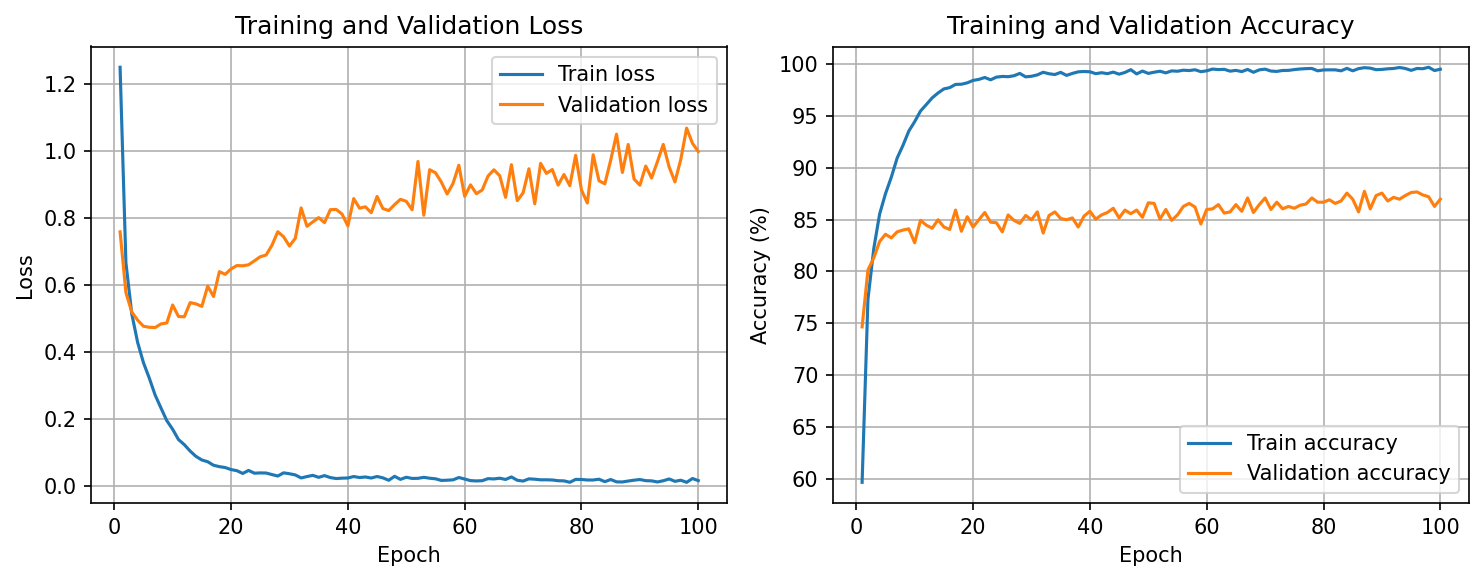


channels [16, 32, 64, 128] | lr 0.001 | 100 epochs | best epoch 87 | val acc 93.34% | test acc 92.58% | test loss 0.4179


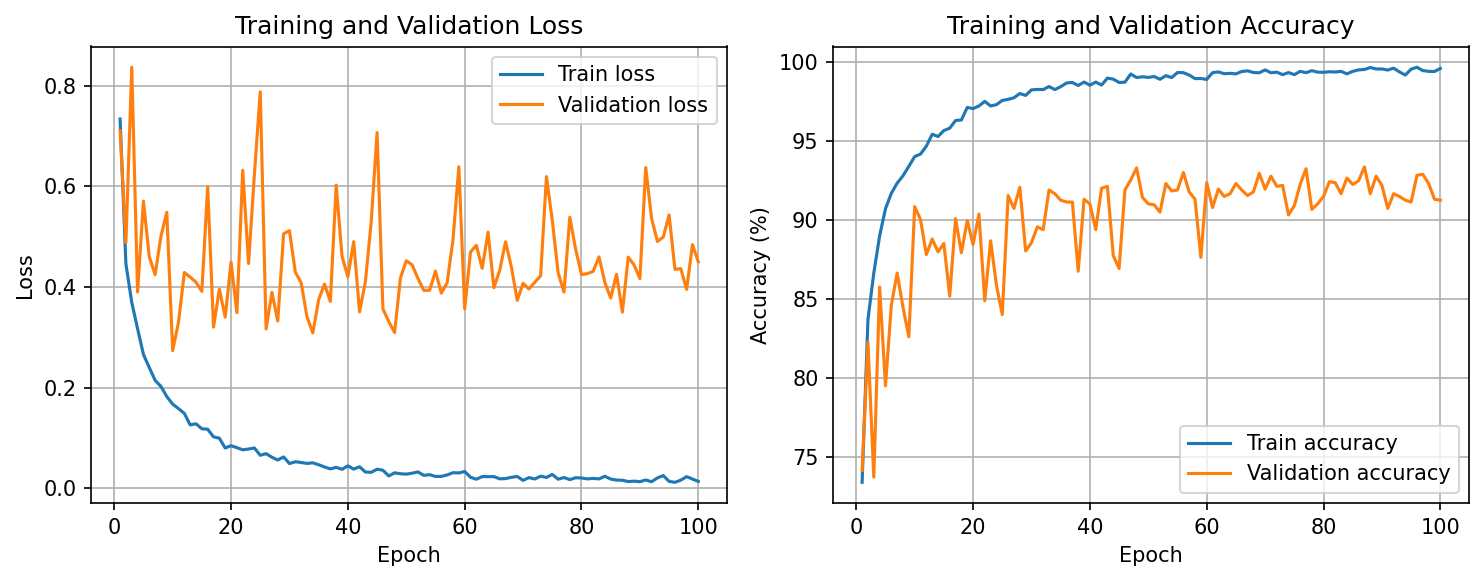


channels [16, 32, 64, 128] | lr 1e-05 | 100 epochs | best epoch 34 | val acc 81.19% | test acc 80.42% | test loss 0.5720


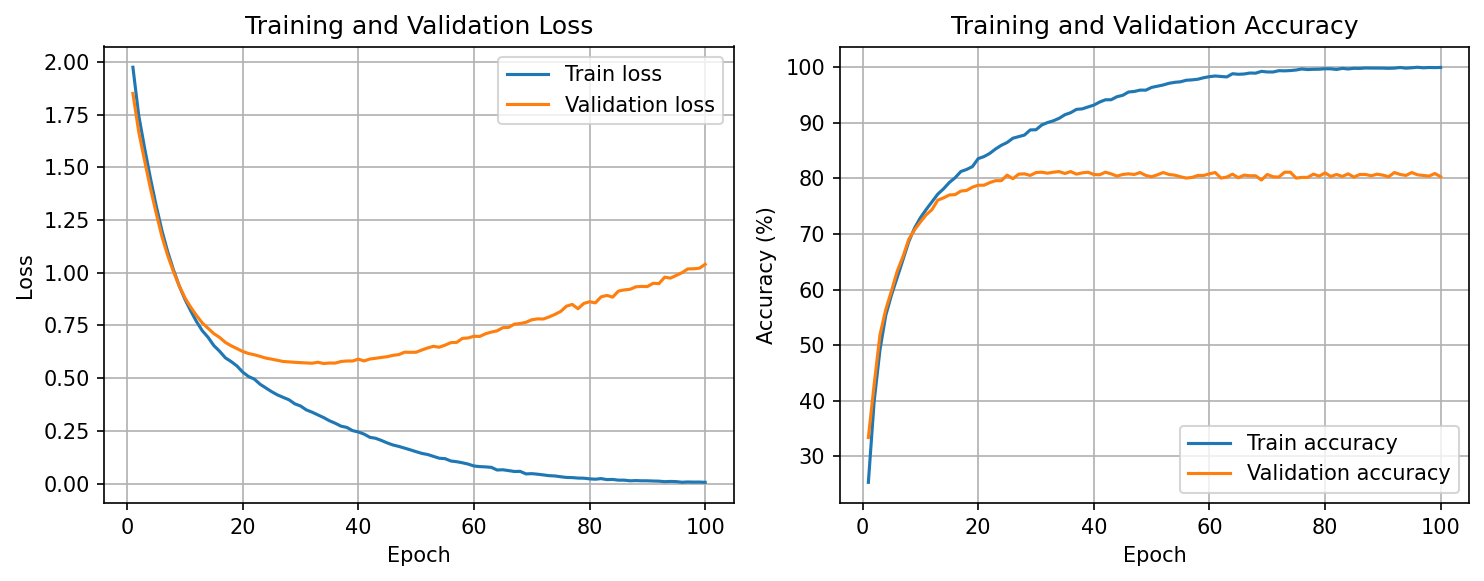


channels [16, 32, 64, 128] | lr 0.0005 | 100 epochs | best epoch 81 | val acc 92.11% | test acc 91.70% | test loss 0.4757


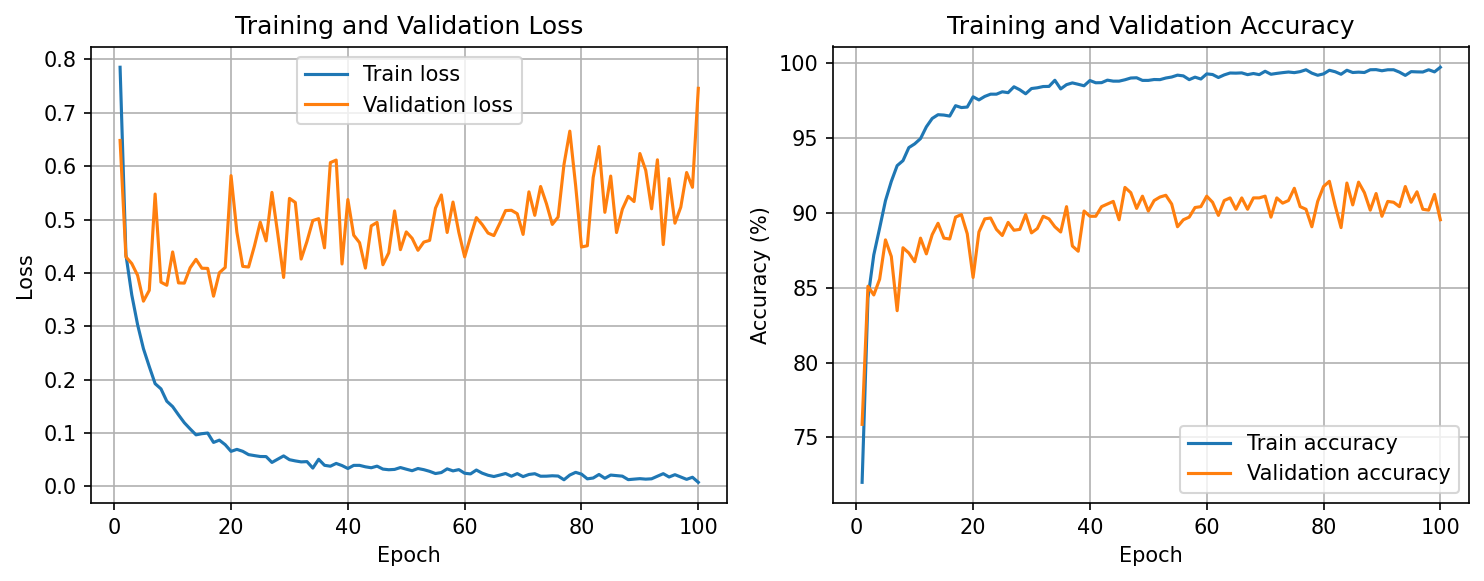


channels [16, 32, 64, 128] | lr 0.00075 | 100 epochs | best epoch 91 | val acc 93.34% | test acc 93.39% | test loss 0.4250


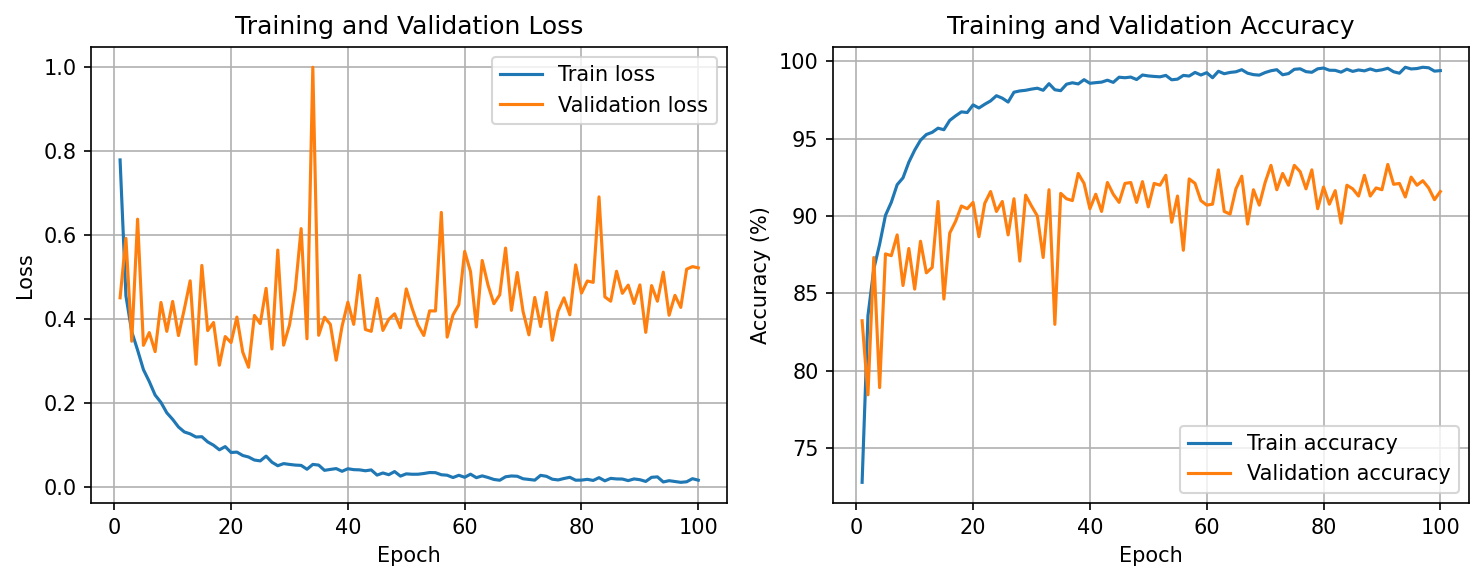


channels [16, 32, 64, 128] | lr 0.000875 | 100 epochs | best epoch 66 | val acc 93.22% | test acc 91.46% | test loss 0.4564


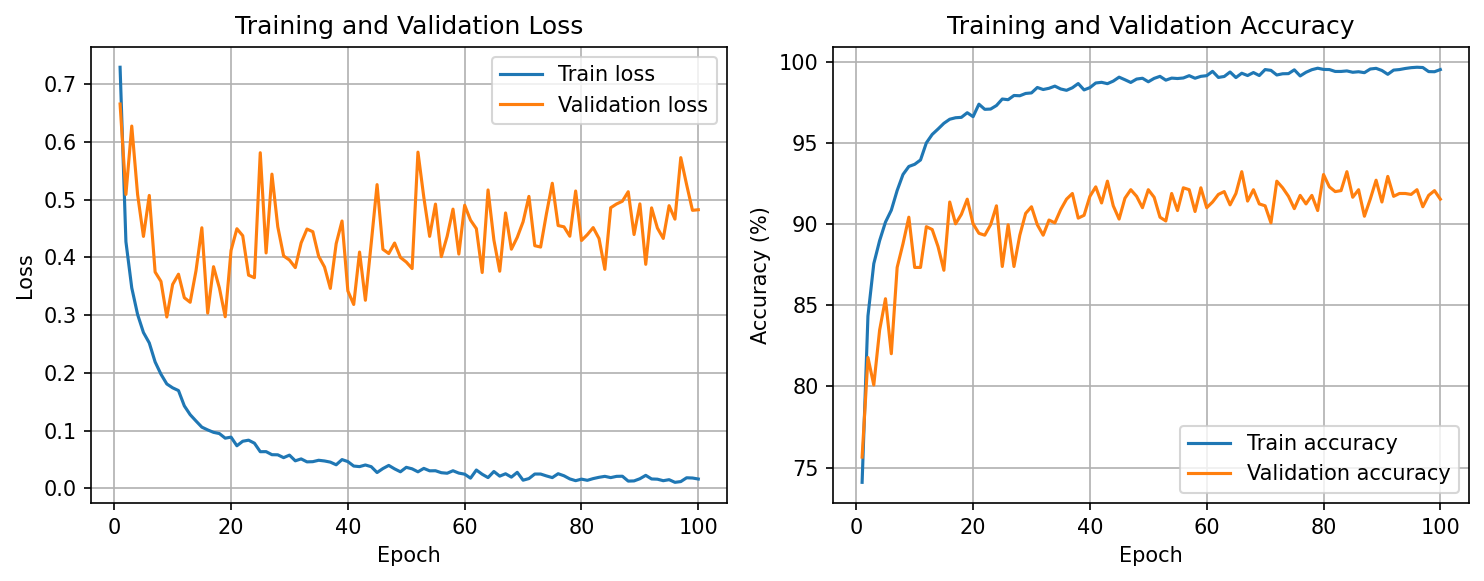

In [42]:

learning_rate_runs = [
    "C16-32-64-128_lr1e-04_ep100",   # 1e-4   baseline
    "C16-32-64-128_lr1e-03_ep100",   # 1e-3
    "C16-32-64-128_lr1e-05_ep100",   # 1e-5
    "C16-32-64-128_lr5e-04_ep100",   # 5e-4
    "C16-32-64-128_lr8e-04_ep100",   # 7.5e-4  (filename rounds to lr8e-04)
    "C16-32-64-128_lr9e-04_ep100",   # 8.75e-4 (filename rounds to lr9e-04)
]
show_curves(learning_rate_runs)


**Reading the learning-rate curves.** The `1e-4` baseline shows the training loss falling steadily while the validation loss flattens and then drifts upward, the classic overfitting gap, and consistent with its high final test loss of 0.9931. The `1e-5` run is the opposite failure mode: both losses decrease very slowly and the best validation accuracy is reached early (epoch 34) before the curve stalls, i.e. underfitting within the 100-epoch budget. The `1e-3` run reaches a much lower validation loss but the validation curve is visibly spiky, which is the instability discussed in Section 14.2. The refinement runs (`5e-4`, `7.5e-4`, `8.75e-4`) sit between these behaviours; `7.5e-4` gives the smoothest high-accuracy curve of the default-channel runs, which is why the high learning-rate region was carried forward.

## Channel-number runs

These runs vary model capacity at a fixed high learning rate (`1e-3`), 100 epochs, comparing `[8,16,32,64]`, `[16,32,64,128]`, `[32,64,128,256]`, and `[64,128,256,512]`.

channels [8, 16, 32, 64] | lr 0.001 | 100 epochs | best epoch 99 | val acc 92.29% | test acc 90.65% | test loss 0.5376


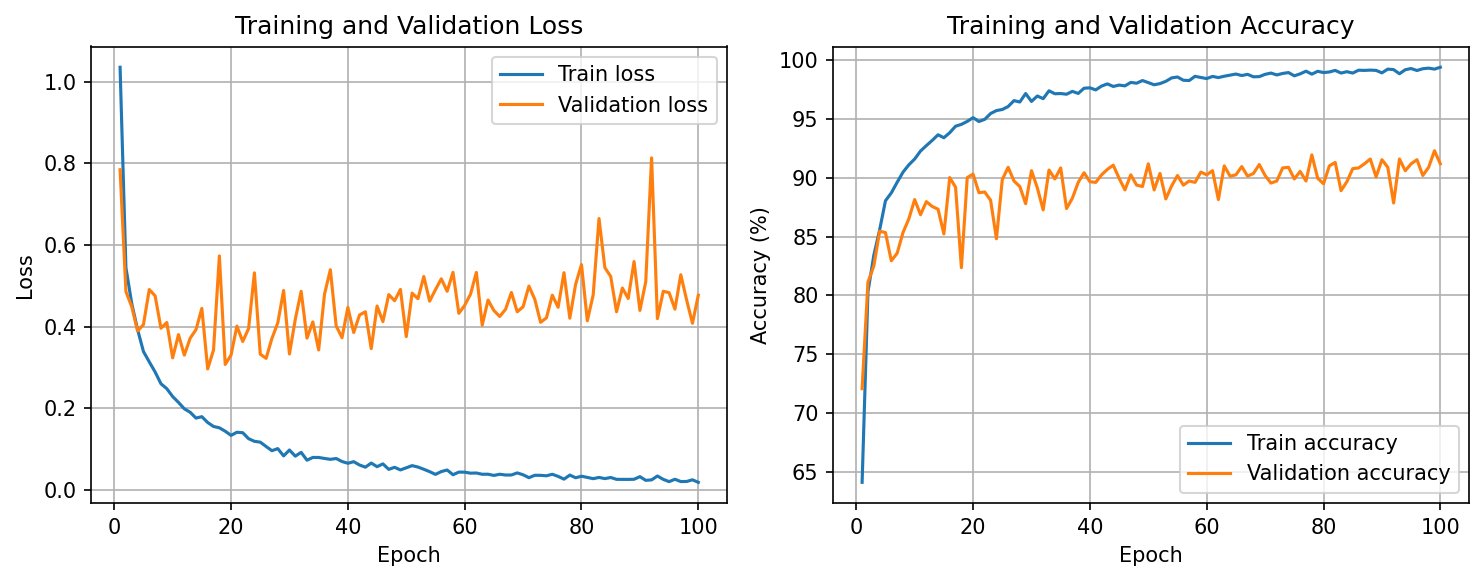


channels [16, 32, 64, 128] | lr 0.001 | 100 epochs | best epoch 87 | val acc 93.34% | test acc 92.58% | test loss 0.4179


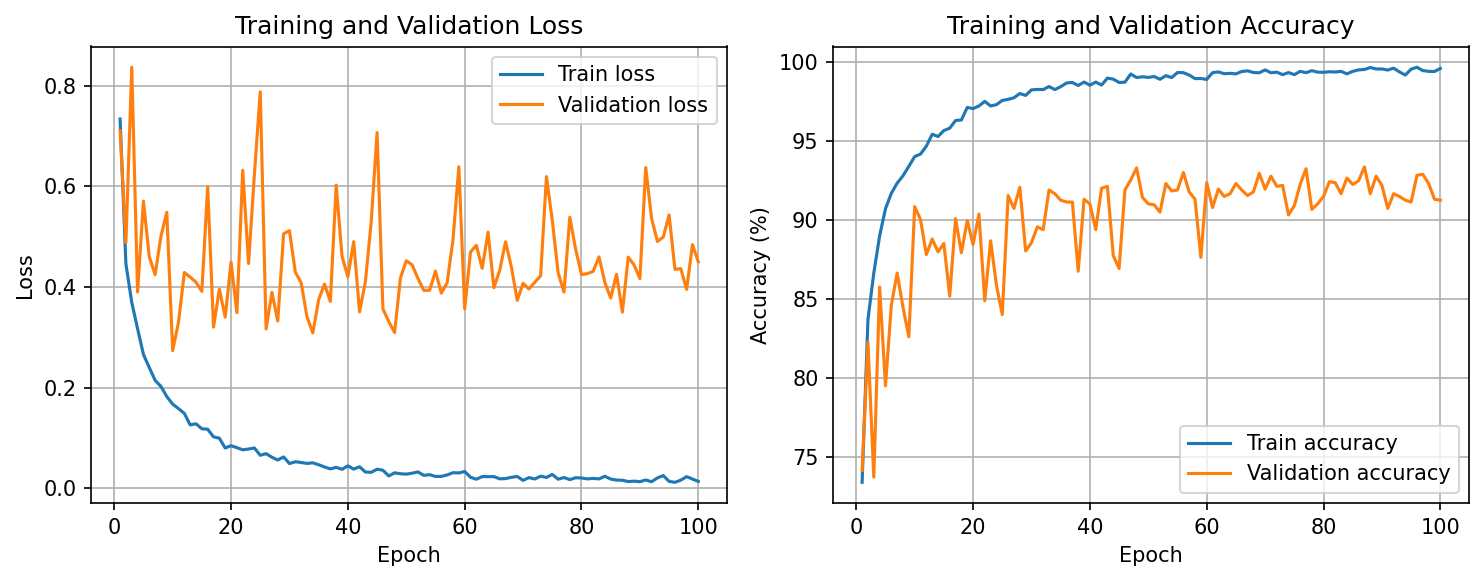


channels [32, 64, 128, 256] | lr 0.001 | 100 epochs | best epoch 99 | val acc 94.39% | test acc 93.07% | test loss 0.3906


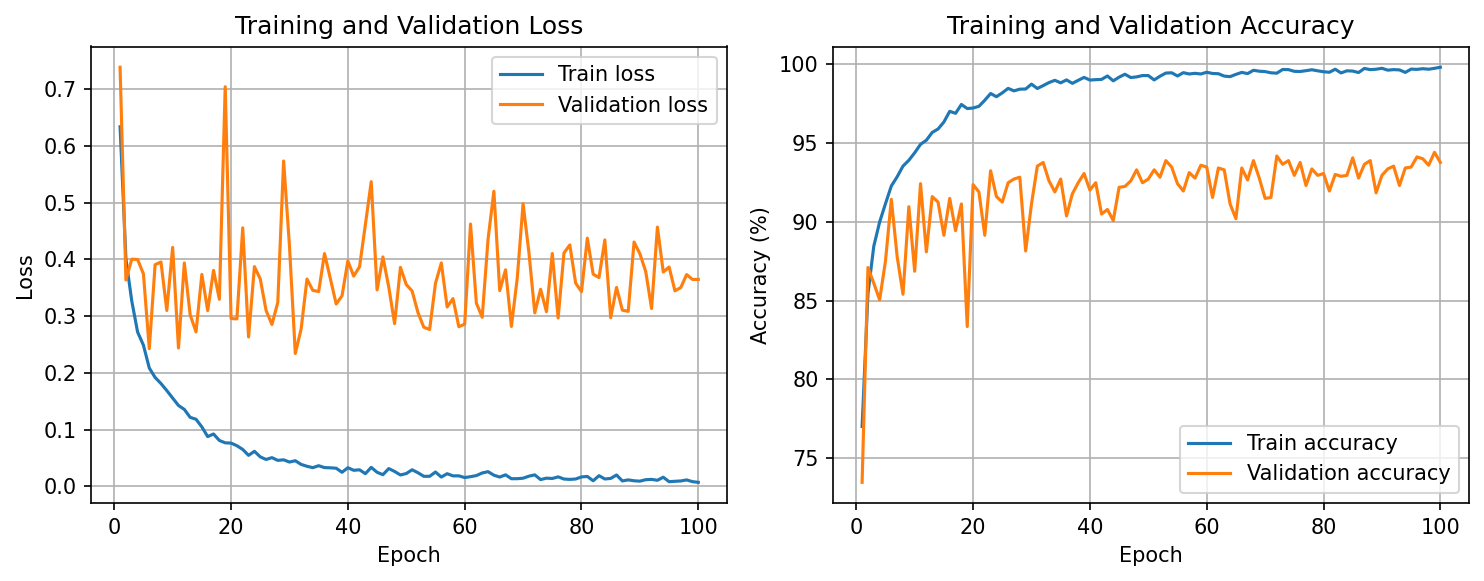


channels [64, 128, 256, 512] | lr 0.001 | 100 epochs | best epoch 89 | val acc 94.45% | test acc 93.77% | test loss 0.2950


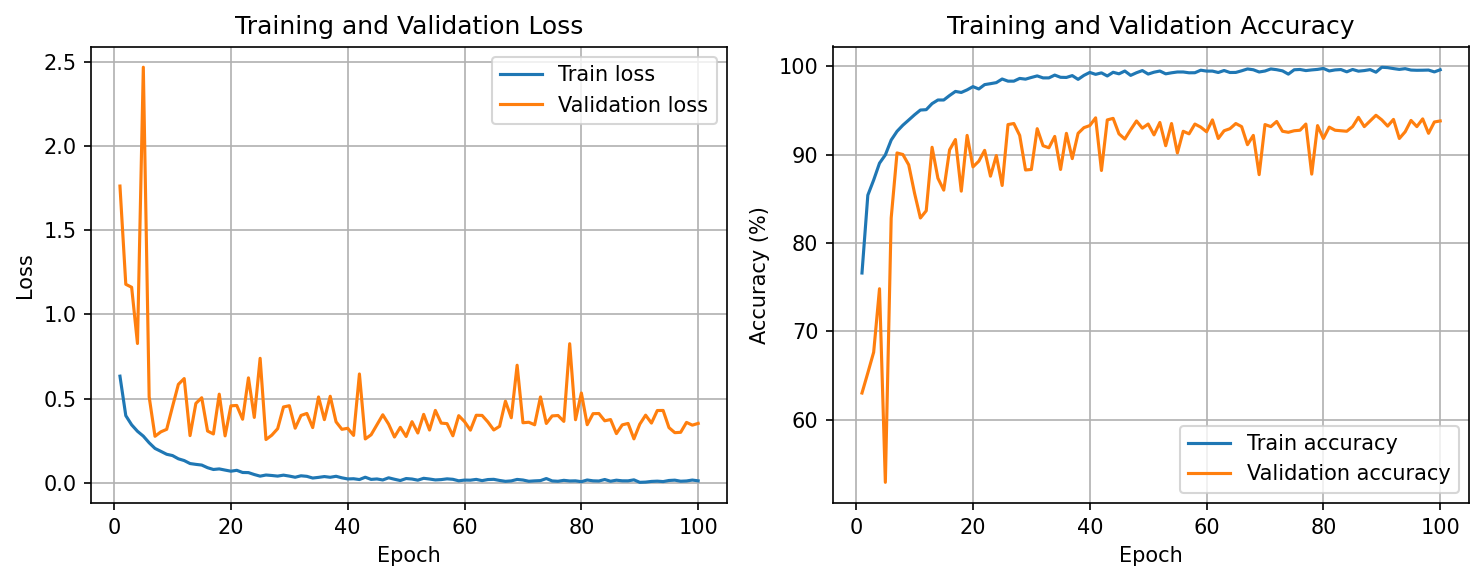

In [43]:

channel_runs = [
    "C8-16-32-64_lr1e-03_ep100",     # smallest capacity
    "C16-32-64-128_lr1e-03_ep100",   # default capacity
    "C32-64-128-256_lr1e-03_ep100",  # increased capacity
    "C64-128-256-512_lr1e-03_ep100", # highest capacity - final selected model
]
show_curves(channel_runs)


**Reading the channel-number curves.** Validation accuracy improves monotonically with width across the range tested: `[8,16,32,64]` is the weakest, and each step up in capacity lifts the validation curve. The widest network `[64,128,256,512]` reaches both the highest validation accuracy (94.45%) and the lowest test loss (0.2950), its validation loss curve is also the most stable of the group, indicating the extra capacity is being used to fit the task rather than to memorise noise. This is the run selected as the final model.

## Epoch runs

These runs study the effect of training length. The first three fix the channels at `[32,64,128,256]` and the learning rate at `7.5e-4`, varying only the maximum number of epochs (50, 100, 200). The fourth applies the best channel configuration `[64,128,256,512]` at 50 epochs: the 100-epoch high-capacity model took roughly 6 hours to train and a 200-epoch run would have taken about twice as long, so a shorter run on the best architecture was tested as a lower-cost alternative.

channels [32, 64, 128, 256] | lr 0.00075 | 50 epochs | best epoch 26 | val acc 93.46% | test acc 92.46% | test loss 0.3082


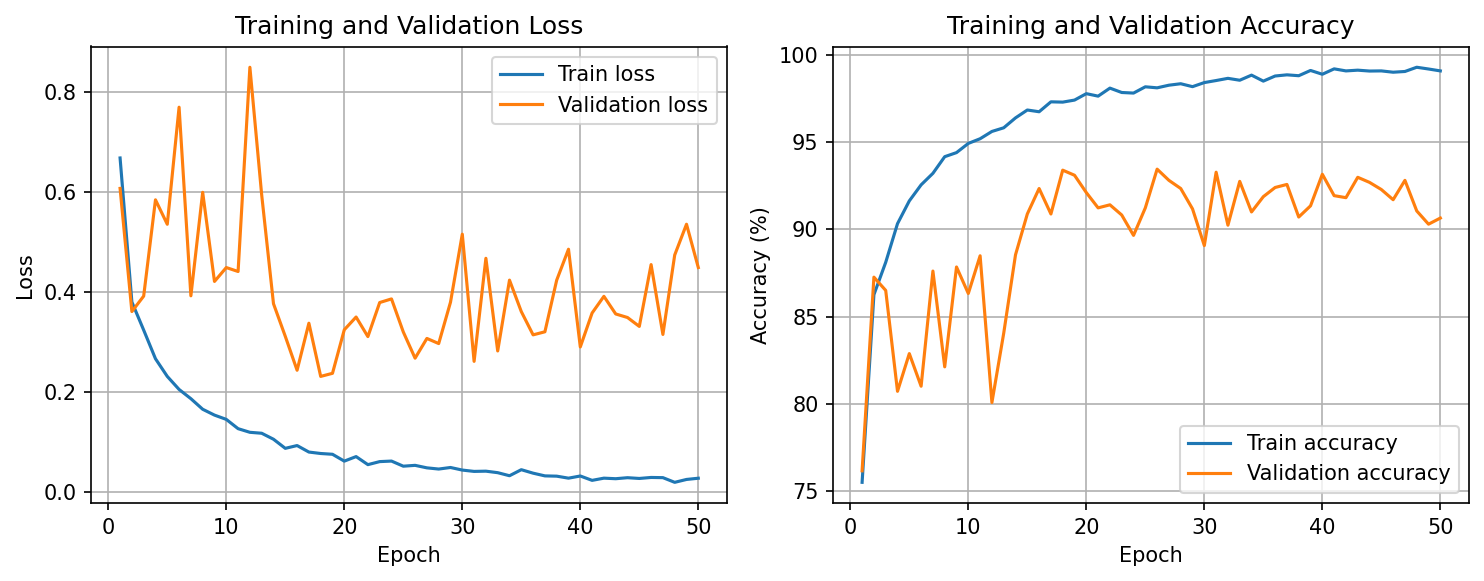


channels [32, 64, 128, 256] | lr 0.001 | 100 epochs | best epoch 99 | val acc 94.39% | test acc 93.07% | test loss 0.3906


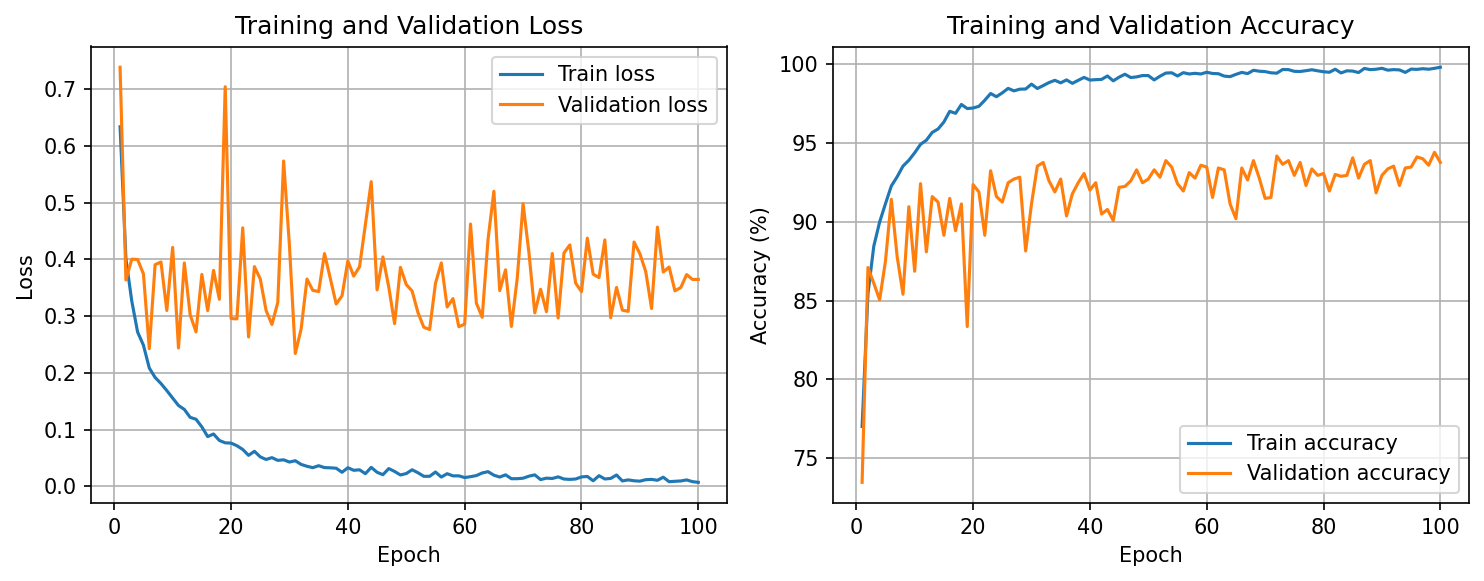


channels [32, 64, 128, 256] | lr 0.00075 | 200 epochs | best epoch 175 | val acc 94.16% | test acc 93.60% | test loss 0.4041


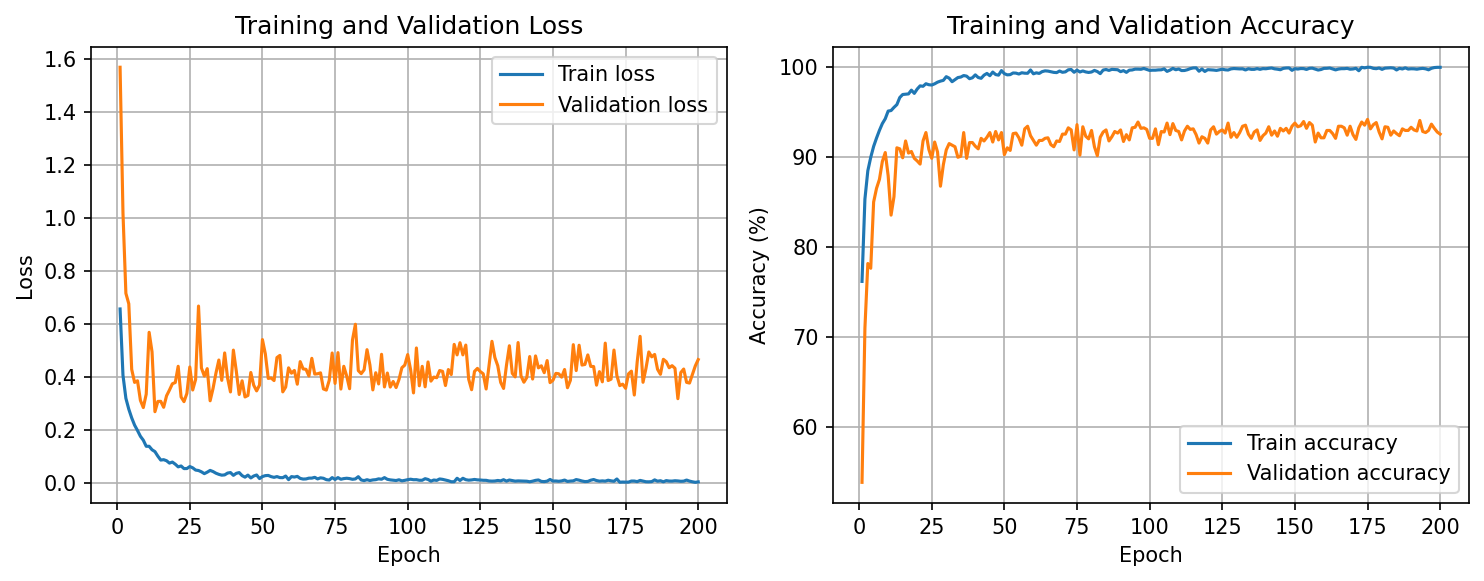


channels [64, 128, 256, 512] | lr 0.00075 | 50 epochs | best epoch 29 | val acc 93.87% | test acc 93.95% | test loss 0.2689


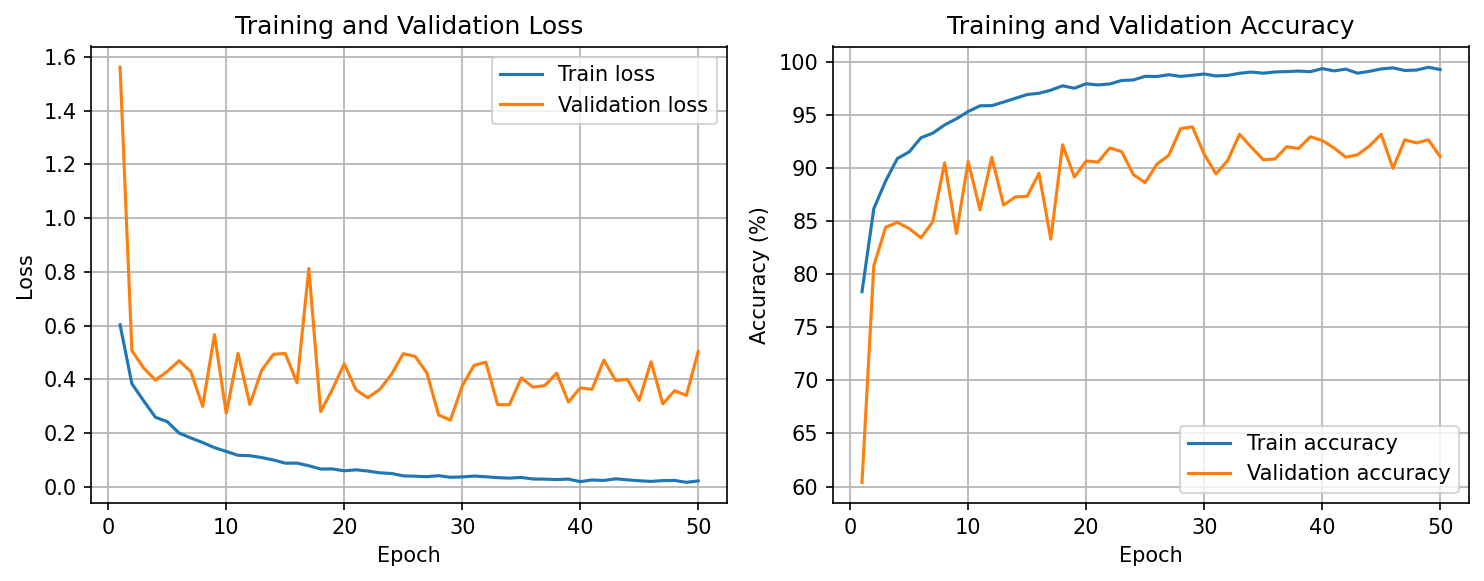


channels [64, 128, 256, 512] | lr 0.00075 | 200 epochs | best epoch 91 | val acc 95.39% | test acc 94.18% | test loss 0.2893


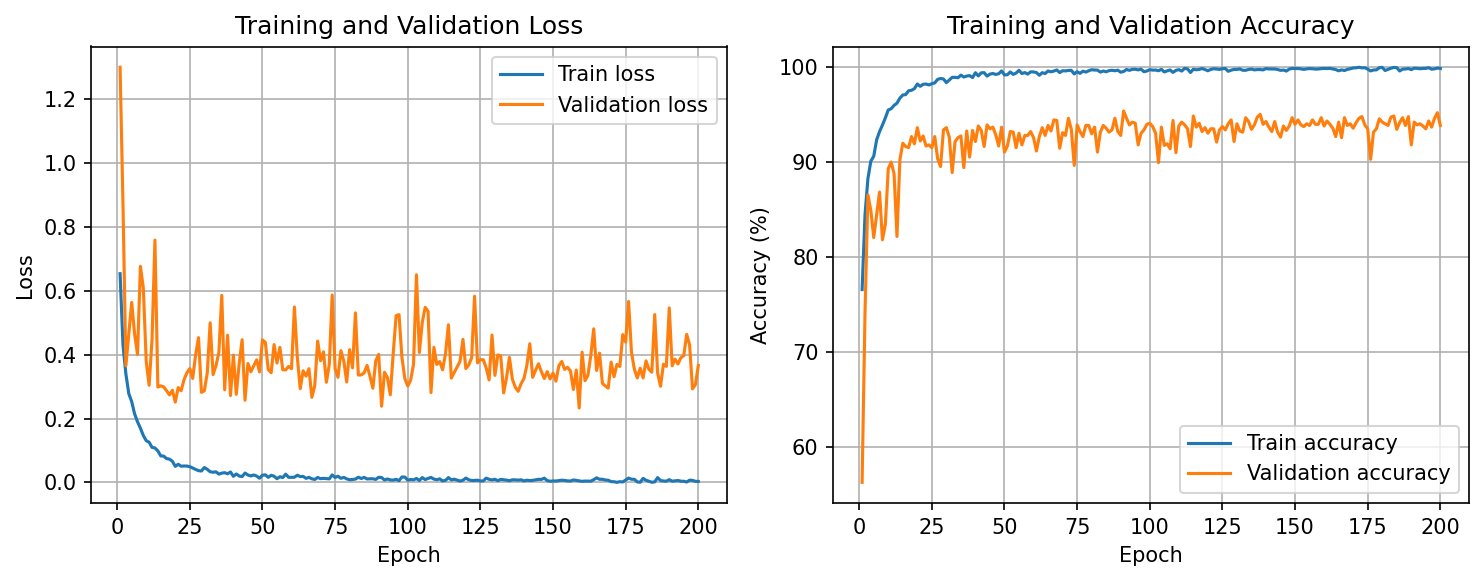

In [44]:

epoch_runs = [
    "C32-64-128-256_lr8e-04_ep50",    # 50 epochs   (filename rounds 7.5e-4 -> lr8e-04)
    "C32-64-128-256_lr1e-03_ep100",   # 100 epochs reference point at this capacity
    "C32-64-128-256_lr8e-04_ep200",   # 200 epochs
    "C64-128-256-512_lr8e-04_ep50",   # 50 epochs at the best (high-capacity) channels
    "C64-128-256-512_lr8e-04_ep200",  # 200 epochs at the best channels - final selected model
]
show_curves(epoch_runs)


**Reading the epoch curves.** For the `[32,64,128,256]` runs, the 50-epoch run stops while the validation loss is still low (best epoch 26, test loss 0.3082) but before validation accuracy has fully converged, so its accuracy is lower; the 200-epoch run pushes accuracy higher but its validation loss rises in the later epochs even as accuracy holds, the overconfidence pattern noted in Section 14.2 and its test loss (0.4041) is worse than the shorter run. For the high-capacity `[64,128,256,512]` runs, the 50-epoch model reaches its best checkpoint at epoch 29 with 93.87% validation accuracy and the lowest test loss of all experiments (0.2689), showing the architecture is strong even with limited training. The 200-epoch model reaches its best checkpoint at epoch 91 and continues to improve on the validation set, ending with the highest validation accuracy (95.39%) and highest test accuracy (94.18%) of all runs; its validation-loss curve is spiky throughout, as in the other high learning-rate runs, but the test loss (0.2893) stays close to the 50-epoch run rather than rising like the `[32,64,128,256]` 200-epoch run. This 200-epoch high-capacity run is the final selected model.

## Final selected model

The curve below is the final selected model `[64, 128, 256, 512]`, learning rate `7.5e-4`, 200 epochs and is the same figure produced in Section 12. It is repeated here for direct comparison with the other runs above: it reaches the highest validation accuracy of all experiments while keeping a test loss close to the best recorded.

channels [64, 128, 256, 512] | lr 0.00075 | 200 epochs | best epoch 91 | val acc 95.39% | test acc 94.18% | test loss 0.2893


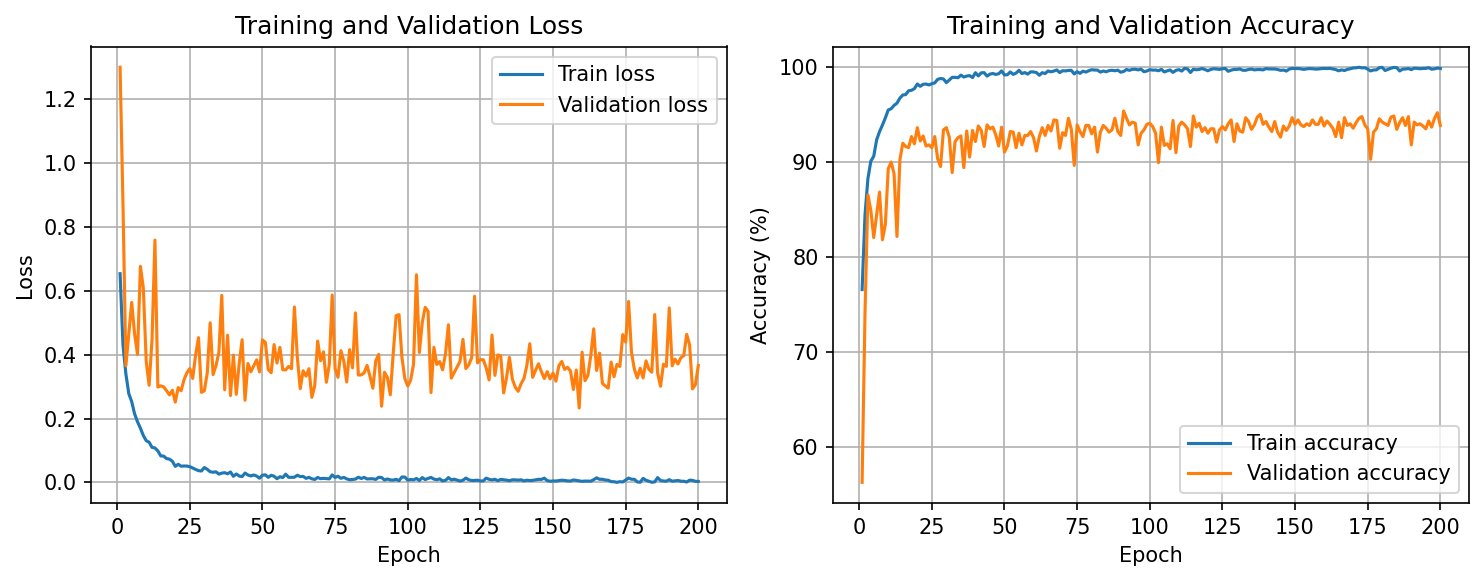

In [46]:
show_curves(["C64-128-256-512_lr8e-04_ep200"])


# Comparison with the Published MedMNIST Baseline

The MedMNIST v2 paper reports baseline results for BloodMNIST. For **ResNet-18 with 28 × 28 inputs**, the published values are:

- ResNet-18 (MedMNIST v2 published baseline): input size `28 × 28`, BloodMNIST AUC `0.998`, BloodMNIST ACC `0.958`.
- ResNet-18-style (this work, final model): input size `28 × 28`, BloodMNIST ACC `0.9418`.

The final model reached a test accuracy of **94.18%**, compared with **95.8%** reported for ResNet-18 at 28 × 28 in the MedMNIST v2 paper. The result is therefore **lower** than the published baseline, by roughly 1.6 percentage points.

**Possible reasons for the lower accuracy.** The comparison is against a single from-scratch run of a prescribed architecture, and several differences are likely to account for the gap:

- **Learning-rate schedule.** The MedMNIST v2 baseline uses an Adam optimiser with an initial learning rate of `1e-3` and a step decay (multiplied by 0.1 after epochs 50 and 75). This implementation uses a constant learning rate, which is consistent with the unstable validation loss observed in Section 14 and would be expected to cost a small amount of final accuracy.
- **Averaging over trials.** The published numbers are the mean of at least three trials, whereas each configuration here was run once, so the reported value includes run-to-run variance.
- **Architecture differences.** The architecture specified in the task sheet (a 7 × 7 stride-2 convolution and 2 × 2 max-pool stem, a fixed eight-block layout, and a C4 → C4/2 → 8 classifier head) is not identical to the standard torchvision ResNet-18 used by the baseline.
- **No data augmentation.** No augmentation was applied during training, which limits the effective size of the training set.

The gap is small and the result is consistent and reproducible from the saved checkpoint, which is reasonable for a model trained from scratch under limited compute and a single run per configuration. No pretrained weights were used, and the official train/validation/test splits were used throughout, with the test set reserved for final evaluation only.

# Future Improvements

The experiments in this report used a deliberately simple training setup with a fixed learning rate, no regularisation beyond batch normalisation, and no data augmentation so that the effect of the three required hyperparameters could be studied in isolation. Several extensions follow naturally from the behaviour observed in the loss curves and would be the logical next steps.

**Learning-rate scheduling.** The strongest runs all used high learning rates (`1e-3` and `7.5e-4`) and all showed a spiky, unstable validation-loss curve (Sections 14.2 and 15). A learning-rate scheduler, for example a step decay or cosine annealing, would keep the large early updates that drive fast convergence while reducing the step size later in training. This would be expected to smooth the validation-loss curve and possibly close part of the gap to the published baseline, whose training schedule does decay the learning rate.

**Regularisation.** Across almost every run the training loss fell close to zero while the validation loss flattened or drifted upward, the classic overfitting signature. Adding dropout in the fully connected head or weight decay in the Adam optimiser would penalise over-confident fitting of training-specific patterns, and would be expected to narrow the train–validation gap, particularly for the high-capacity `[64,128,256,512]` model, where that gap was widest.

**Data augmentation.** No augmentation was used, so the model saw each of the 11,959 training images in a fixed form every epoch. Light augmentation suited to microscope images, small rotations, flips, or brightness jitter, would effectively enlarge the training set and expose the model to more variation. This is one of the differences between this setup and the published MedMNIST baseline.

**Formal early stopping.** This report already saves the checkpoint with the highest validation accuracy rather than the final-epoch model, which captures most of the benefit of early stopping. A formal early-stopping criterion, halting training once validation accuracy has not improved for a set number of epochs, would additionally cut wasted computation, which matters given that the 200-epoch high-capacity run was the most expensive experiment performed.

**Wider hyperparameter coverage.** Channel widths beyond `[64,128,256,512]` and longer schedules were not explored because of training cost. With more compute, a more systematic search or the optional architectural modifications suggested in the task sheet could test whether the gap to the published baseline can be closed further.

# Reproducibility and Model Sharing

Every run saves a checkpoint (`checkpoints/best_resnet18_<run_tag>.pt`) containing the model weights together with the channel configuration, learning rate, epoch count, and best epoch. Section 13 reloads any of these checkpoints, rebuilds the model from the stored channel configuration, and evaluates it on the test set, so the results in Section 14 are reproducible without retraining. A per-run training history and a combined `experiment_summary.csv` are also written to the `checkpoints/` folder.

As required by Task 5 of the task sheet, all trained checkpoints including those from the different hyperparameter runs, have been uploaded to cloud storage:

- **Shared drive link:** https://uq-my.sharepoint.com/:f:/g/personal/s4743556_uq_edu_au/IgD-SXeyHaBdTKvgFHlXak7_AcfBuGOHnVAi5xZ1Eko07H4?e=YD5lD1
- **Upload timestamp:** *8:37AM 15/05/2026*

To evaluate a specific model, set `EVAL_MODEL_PATH` in Section 13 to the corresponding `.pt` file and run the notebook from the top, skipping only the training loop in Section 11.

# Acknowledgement of AI Use

I acknowledge the use of ChatGPT (OpenAI, https://chat.openai.com/) to support the completion of this assessment. ChatGPT was used to help clarify technical concepts related to convolutional neural networks, ResNet-style architectures, checkpointing, validation/test evaluation, overfitting, learning-rate selection, and hyperparameter tuning.

ChatGPT was also used to assist with structuring the Jupyter Notebook, interpreting training and validation curves, organising experimental results, refining the report wording, and ensuring the discussion was consistent with the task sheet requirements.

All code implementations, model training, experimental runs, checkpoint generation, result collection, final model selection, and final explanations were completed, checked, and verified by me.